# sw_plain_comparison.ipynb

# Import

In [123]:
import numpy as np
import pandas as pd
import xarray as xr
from datetime import *
import glob
from vvmtools.analyze import DataRetriever
# --- self define modules --- #
import importlib
import sys
sys.path.append('../../src/taiwanvvm/')
import PlotTools
importlib.reload(PlotTools);

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmaps
import seaborn.colors.xkcd_rgb as c
from matplotlib.gridspec import GridSpec

# Utilities

## Data

In [94]:
topo_fpath = '../../data/raw/vvm_TOPO.nc'   # high-resolution (500m) Taiwan topography

## Common Instances

In [113]:
plottools_vvm = PlotTools.PlotTools_vvm()

In [82]:
lat_plain, lon_plain = (21.5, 23.5), (120, 120.5)

## !!

In [124]:
pcp_fpath = ''
taiwanvvm_fpath = ''

In [125]:
box_figpath   = ""

In [126]:
cwapcp_figpath= ""

In [127]:
vvmpcp_figpath= ""

## Simulation Dates

In [6]:
dlist_swsim = ['20140810', '20140813',
               '20150522', '20150524', '20150719', '20150720', '20150809', '20150828', '20150829', 
               '20160610', '20160611', '20160711', '20160712', '20160902',
               '20170602', '20170614', '20170615', '20170731',
               '20180617', '20180618', '20180619', '20180620', '20180701', '20180702', '20180815', '20180828',
               '20190611', '20190710', '20190810', '20190815']
len(dlist_swsim)

30

## Class: weather table

In [7]:
class weather_table():
    def __init__(self, year_list:list, month_list:list, 
                 special_start_date:str=False, special_end_date:str=False, 
                 lat_range=(None, None), lon_range=(None, None)):
        self.YEARS     = year_list
        self.MONTHS    = month_list
        self.STARTDATE = self._convert_to_dobj(special_start_date) if special_start_date else None
        self.ENDDATE   = self._convert_to_dobj(special_end_date) if special_end_date else None
        self.LATRANGE  = lat_range if lat_range[0]>lat_range[1] and \
                         lat_range[0] is not None and lat_range[1] is not None \
                         else lat_range[::-1]  # for ERA5 data
        self.LONRANGE  = lon_range
    
    def _convert_to_dobj(self, date):
        """
        Convert a date string into a datetime object.
        Two types of string format are supported: 20051218 or 2005-12-18.
        """
        if isinstance(date, str):
            if len(date)>8:
                dateobj = datetime.strptime(date, '%Y-%m-%d')
            else:
                dateobj = datetime.strptime(date, '%Y%m%d')
        else:
            dateobj = date
        return dateobj

    
    def get_cwb_precip_table(self, date:str, accumulate_daily=False):
        # File list
        cwb_fpath = f'{pcp_fpath}/{date[:4]}/{date[4:6]}/{date}'
        cwb_flist = sorted(glob.glob(f'{cwb_fpath}/{date}*'))
        # Define column widths based on README
        col_widths = [7, 10, 9, 7, 7, 7, 7, 7, 7, 7, 7, 3]
        # Define the column names
        col_names = ['stno', 'lon', 'lat', 'elv', 'PS', 'T', 'RH',
                     'WS', 'WD', 'PP', 'odSS01', 'ojits']
        # Use read_fwf to read the fixed-width formatted file
        for hh in range(len(cwb_flist)):
            data = pd.read_fwf(cwb_flist[hh], widths=col_widths, names=col_names)
            cwb_lon, cwb_lat, cwb_pcp = data[['lon', 'lat', 'PP']].values.T
            self.cwb_LON = cwb_lon
            self.cwb_LAT = cwb_lat
            
            if accumulate_daily:                              # target_pcp is daily precip.
                if hh<1:
                    target_pcp = cwb_pcp
                else:
                    target_pcp = np.add(target_pcp, cwb_pcp)
                
            else:                                            # target_pcp is hourly precip.
                if hh<1:
                    target_pcp= cwb_pcp[np.newaxis, ...]
                else:
                    target_pcp= np.concatenate((target_pcp, cwb_pcp[np.newaxis, ...]), axis=0)
        target_pcp    = np.where(target_pcp>=0., target_pcp, np.nan)
        if accumulate_daily:
            pcp_table = pd.DataFrame({'stn_lon':cwb_lon, 'stn_lat':cwb_lat, 'precip':target_pcp})
        else:
            raise ValueError("Table for hourly precipitation isn't built yet.")
        return pcp_table
                
wtab_module_all  = weather_table(year_list=np.arange(2001, 2020).tolist(), month_list=np.arange(4, 10).tolist(), 
                                 lat_range=(22, 20), lon_range=(115, 119))

In [8]:
wtab_module_all.get_cwb_precip_table(date=dlist_swsim[0], accumulate_daily=True)

,stn_lon,stn_lat,precip
0,121.4420,24.9976,NaN
1,121.4489,25.1649,0.0
2,121.5297,25.1826,0.0
3,121.5149,25.0377,NaN
4,121.5445,25.1621,0.0
...,...,...,...
735,120.8240,22.2643,NaN
736,120.3753,23.2533,NaN
737,121.0094,22.8233,NaN
738,120.7542,23.0749,NaN


## Class: plot_analysis()

In [95]:
class Plot_analysis():
    def __init__(self):
        self.proj = ccrs.PlateCarree()
        self.ds_topo = xr.open_dataset(topo_fpath)        
    
    def Axe_map(self, fig, gs, 
                xlim_, ylim_, **grid_info):
        # Set map extent
        axe  = fig.add_subplot(gs, projection=self.proj)
        axe.set_extent([xlim_[0], xlim_[-1], ylim_[0], ylim_[-1]], crs=self.proj)
        # Set additional grid information
        if len(grid_info)>0:
            if grid_info['xloc_'] is not None:
                axe.set_xticks(grid_info['xloc_'], crs=self.proj)
                axe.set_xticklabels(['' for i in range(len(grid_info['xloc_']))])  # default: no tick labels
            if grid_info['yloc_'] is not None:
                axe.set_yticks(grid_info['yloc_'], crs=self.proj)
                axe.set_yticklabels(['' for i in range(len(grid_info['yloc_']))])
            gl = axe.gridlines(xlocs=grid_info['xloc_'], ylocs=grid_info['yloc_'], 
                               draw_labels=False)
        return axe
    
    def Plot_cartopy_map(self, axe):
        axe.add_feature(cfeature.LAND,color='grey',alpha=0.1)
        axe.coastlines(resolution='50m', color='black', linewidth=1)
        return axe
    
    def Plot_vvm_map(self, axe, color, linewidth):
        axe.contour(self.ds_topo.lon, self.ds_topo.lat, self.ds_topo.topo, 
                    levels=np.array([-1e-3, 1e-3]), 
                    colors=color, linewidths=linewidth)
    
    def Plot_vvm_topo(self, axe, color, linewidth=None):
        topo_bounds= np.arange(0, 3500.1, 500)
        alpha_list = [0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
        cmap_topo  = colors.ListedColormap([(0, 0, 0, i) for i in alpha_list])
        norm_      = colors.BoundaryNorm(topo_bounds, cmap_topo.N, extend='max')
        imtopoh    = axe.contourf(self.ds_topo.lon, self.ds_topo.lat, self.ds_topo.height*1e3, 
                                  levels=topo_bounds, 
                                  cmap=cmap_topo, norm=norm_, extend='max', antialiased=1)
        if linewidth is not None:
            axe.contour(self.ds_topo.lon, self.ds_topo.lat, self.ds_topo.height*1e3, levels=np.array([499.99, 500.01]), 
                        colors=color, linewidths=linewidth)
        else:
            pass
        return imtopoh
        
    def Plot_twcwb_pcp(self, axe, 
                       lon, lat, precip,
                       s, alpha, precip_bounds=[1, 2, 6, 10, 15, 20, 30, 40, 50, 70, 90, 110, 130, 150, 200, 300], edgecolors=None):
        bounds= np.array(precip_bounds)
        cmap  = cmaps.WhiteBlueGreenYellowRed
        norm  = colors.BoundaryNorm(bounds, cmap.N, extend='both')
        im    = axe.scatter(lon, lat, c=precip, s=s, 
                            cmap=cmap, norm=norm, alpha=alpha, edgecolors=edgecolors)
        return im
    
plottools = Plot_analysis()

# Sample TaiwanVVM rainfall at rain gauge points

In [9]:
def cal_vvm_dpcp(case:str, date:str, domain_range:tuple=(None, None, None, None), land_only:bool=True):
    # Check
    print(f"Calculating daily precipitation. The Land-only option is now: {land_only}.")
    # Calculation
    j1, j2, i1, i2 = domain_range
    if case == 'sw':
        if date == '20180815':
            date       = '20140815'   # typo in file name
        check          = glob.glob(f"{taiwanvvm_fpath}/taiwanvvm_sw/case_sw_{date}")
        if len(check)<1:
            fname      = glob.glob(f"{taiwanvvm_fpath}/taiwanvvm_sw/case_sw_{date}_sim*")[0]
            vvmtools_date  = DataRetriever(fname)
        else:
            fname      = check[0]
            vvmtools_date  = DataRetriever(fname)
    elif case == 'at':
        vvmtools_date  = DataRetriever(f"{taiwanvvm_fpath}/taiwanvvm_at/tpe{date}nor")
    else:
        raise ValueError("Argument `case` should be either 'sw' or 'at'.")
    arr_pcp_all    = vvmtools_date.get_var_parallel(var='sprec', time_steps=np.arange(145))
    arr_day_pcp    = np.sum(arr_pcp_all, axis=0)*3600/6
    if land_only:
        arr_day_pcp = np.where(plottools.ds_topo.topo>0, arr_day_pcp, np.nan)
    return arr_day_pcp[j1:j2, i1:i2]

In [10]:
def Get_gauge_taiwanvvm(date:str, lat_range:tuple, lon_range:tuple):
    # Load data
    pcp_table                 = wtab_module_all.get_cwb_precip_table(date=date, accumulate_daily=True)
    stn_lon, stn_lat, cwa_pcp = pcp_table['stn_lon'], pcp_table['stn_lat'], pcp_table['precip']
    
    dd_vvm_pcp = cal_vvm_dpcp(case='sw', date=date, land_only=False)
    vvm_topo   = xr.open_dataset('../../data/raw/vvm_TOPO.nc')
    da_500m    = xr.DataArray(data=dd_vvm_pcp, dims=["lat", "lon"], coords=dict(lon=(["lon"], vvm_topo.lon.data), lat=(["lat"], vvm_topo.lat.data)))
    # print(da_500m.max(skipna=True))
    
    # Gauge points
    nanmask = ~np.isnan(cwa_pcp)
    regmask = (stn_lon>=min(lon_range))&(stn_lon<=max(lon_range))&(stn_lat>=min(lat_range))&(stn_lat<=max(lat_range))
    valid_stn_num = cwa_pcp[nanmask&regmask].shape[0]
    # print(stn_lon[nanmask&regmask])
    vvm_pcp_sample= np.zeros(valid_stn_num)
    vvm_lon_sample= np.zeros(valid_stn_num)
    vvm_lat_sample= np.zeros(valid_stn_num)
    for i in range(valid_stn_num):
        select_vvm_point = da_500m.sel(lon=stn_lon[nanmask&regmask].iloc[i], lat=stn_lat[nanmask&regmask].iloc[i], method='nearest')
        vvm_pcp_sample[i]= select_vvm_point.data
        vvm_lon_sample[i]= select_vvm_point.lon.data
        vvm_lat_sample[i]= select_vvm_point.lat.data
    return cwa_pcp[nanmask&regmask], vvm_pcp_sample

# Box plot of coast/plain rainfall

In [85]:
def Plot_plain_box_compar(datelist:list, figname=False):
    medianprops = dict(linestyle='-', linewidth=1.5, color='k')
    boxprops    = dict(linestyle='-', linewidth=1.5, color='k')
    whiskerprops= dict(linestyle='-', linewidth=1.5, color='k')
    capprops    = dict(linestyle='-', linewidth=1.5, color='k')
    cwaprops    = dict(linestyle='-', linewidth=1.5, color='k')
    vvmprops    = dict(linestyle='-', linewidth=1.5, color=c['sapphire'])
    
    fig, ax = plt.subplots(figsize=(25, 4))
    ax.grid(axis='y', lw=0.5, ls=':', color='grey')
    xticks  = []
    for i, dd in enumerate(datelist):
        # ax.boxplot([cwa_plain[dd], vvm_plain[dd]], positions=[i-0.1, i+0.1], widths=0.15, sym='k+',
        #            medianprops=medianprops, boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops)
        ax.boxplot([cwa_plain[dd]], positions=[i-0.1], widths=0.15, sym='k+',
                   medianprops=cwaprops, boxprops=cwaprops, whiskerprops=cwaprops, capprops=cwaprops)
        ax.boxplot([vvm_plain[dd]], positions=[i+0.1], widths=0.15, sym='k+',
                   medianprops=vvmprops, boxprops=vvmprops, whiskerprops=vvmprops, capprops=vvmprops)
        ax.text(x=i-0.285, y=295, s=dd, fontsize=14)
        xticks+= [i-0.1, i+0.1]
        
    ax.set_xlim([-1, 10])
    ax.set_ylim(0, 280)
    ax.set_ylabel("(mm/day)", fontsize=14)
    ax.set_xticks(xticks)
    ax.set_xticklabels(["CWA   " if i%2==0 else "   VVM" for i in range(len(datelist)*2)], fontsize=14)
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 2 != 0: label.set_color(c['sapphire'])
    ax.set_yticks(np.arange(0, 280.1, 50))
    ax.set_yticklabels(np.arange(0, 280.1, 50).astype(int), fontsize=14)
    if figname:
        plt.savefig(f"{box_figpath}/{figname}.png", bbox_inches='tight', facecolor='w', dpi=400)
    plt.show()

In [65]:
# Calculate the coast/plain rainfall for all dates
cwa_plain    = dict(zip(dlist_swsim, [[] for i in range(len(dlist_swsim))]))
vvm_plain    = dict(zip(dlist_swsim, [[] for i in range(len(dlist_swsim))]))
plain_avg_pr = []
for dd in dlist_swsim:
    cwa_tmp, vvm_tmp = Get_gauge_taiwanvvm(date=dd, lat_range=lat_plain, lon_range=lon_plain)
    cwa_plain[dd]    = cwa_tmp
    vvm_plain[dd]    = vvm_tmp
    plain_avg_pr.append(np.nanmean(cwa_tmp))

Calculating daily precipitation. The Land-only option is now: False.


Calculating daily precipitation. The Land-only option is now: False.


Calculating daily precipitation. The Land-only option is now: False.


Calculating daily precipitation. The Land-only option is now: False.


Calculating daily precipitation. The Land-only option is now: False.


...

Calculating daily precipitation. The Land-only option is now: False.


Calculating daily precipitation. The Land-only option is now: False.


Calculating daily precipitation. The Land-only option is now: False.


Calculating daily precipitation. The Land-only option is now: False.


Calculating daily precipitation. The Land-only option is now: False.


In [66]:
# Arranging dates from the highest average plain rainfall to the lowest
dlist_swsim_sort = np.asarray(dlist_swsim)[np.argsort(plain_avg_pr)[::-1]]
dlist_swsim_sort = dlist_swsim_sort.tolist()

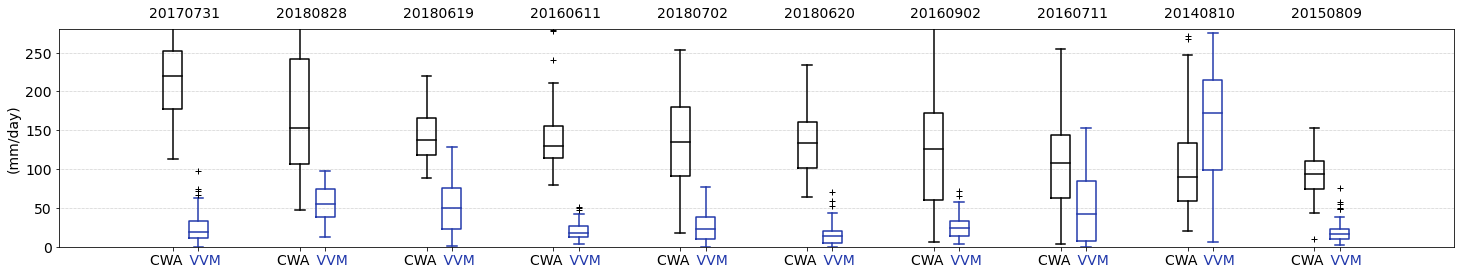

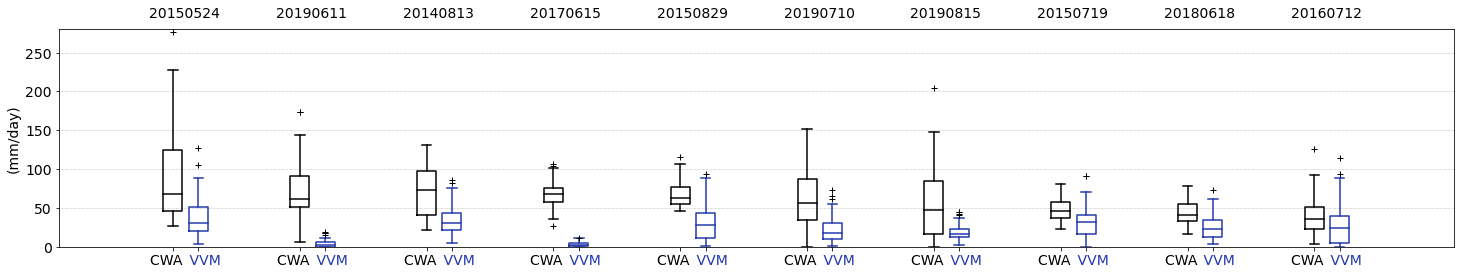

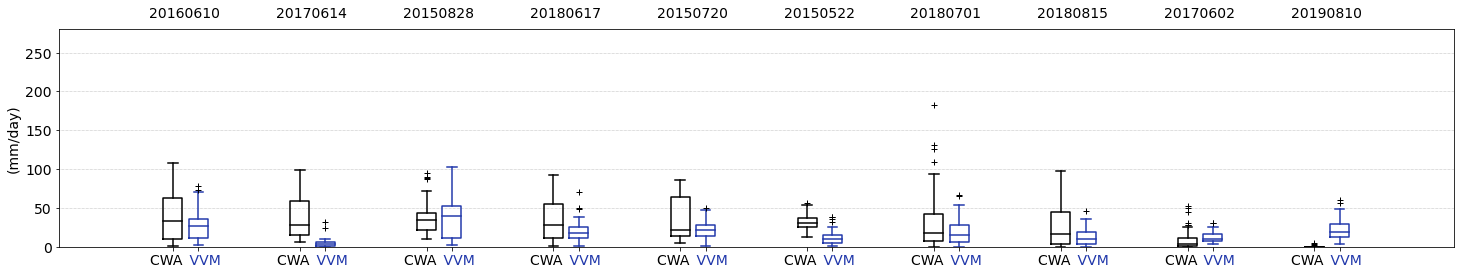

In [86]:
for i in range(3):
    Plot_plain_box_compar(datelist=dlist_swsim_sort[i*10:(i+1)*10], figname=f'group{i}')

# Map comparison

## OBS

In [101]:
def Plot_cwa_dpcp_add_settings(date:str, regional_rect=False, figtitle=False, figname=False):
    # Data initialize
    pcp_table = wtab_module_all.get_cwb_precip_table(date, accumulate_daily=True)
    bounds    = np.array([1, 2, 6, 10, 15, 20, 30, 40, 50, 70, 90, 110, 130, 150, 200, 300])
    # Figure initialize
    fig = plt.figure(figsize=(4, 8))
    gs  = GridSpec(1, 1, figure=fig)
    ## Plot:
    ax1   = plottools.Axe_map(fig, gs[0], xlim_=[119.95, 122.05], ylim_=[21.85, 25.5], 
                              xloc_=np.arange(120, 122.1, 1), yloc_=np.arange(22, 25.1, 1))
    plottools.Plot_vvm_map(ax1, c['dark grey'], 1.5)  # coastline
    temp1 = np.argsort(pcp_table['precip'].values)
    imcwb = plottools.Plot_twcwb_pcp(ax1, pcp_table['stn_lon'].iloc[temp1], pcp_table['stn_lat'].iloc[temp1], pcp_table['precip'].iloc[temp1], s=80, alpha=0.8, precip_bounds=bounds)
    # temp1 = np.argsort(dict_cwa_pcp_demo[date])
    # imcwb = plottools.Plot_twcwb_pcp(ax1, 
    #                                  dict_cwa_pcp_demo['stn_lon'][temp1], 
    #                                  dict_cwa_pcp_demo['stn_lat'][temp1], 
    #                                  dict_cwa_pcp_demo[date][temp1], 
    #                                  s=80, alpha=0.8, precip_bounds=bounds)
    
    cax  = fig.add_axes([ax1.get_position().x1+0.28, ax1.get_position().y0, 0.03, ax1.get_position().height])
    cbar = fig.colorbar(imcwb, orientation='vertical', cax=cax)
    cbar.solids.set(alpha=1)  # Default: set cbar to full color (w/out tranparency)
    cbar.set_ticks(ticks=bounds, labels=[int(i) for i in bounds])
    cbar.ax.tick_params(labelsize=13)
    cbar.set_label('mm/day', fontsize=16)
    cbar.outline.set_linewidth(1.5)
    
    topo_bounds= np.arange(0, 3500.1, 500)
    imtopoh    = plottools.Plot_vvm_topo(ax1, c['dark grey'], 0.5)
    cax  = fig.add_axes([ax1.get_position().x1+0.04, ax1.get_position().y0, 0.03, ax1.get_position().height])
    cbar = fig.colorbar(imtopoh, orientation='vertical', cax=cax)
    cbar.set_ticks(ticks=topo_bounds, labels=[f"{i/1e3:.1f}" for i in topo_bounds])
    cbar.ax.tick_params(labelsize=13)
    cbar.set_label('Topography Height (km)', fontsize=16)
    cbar.outline.set_linewidth(1.5)
    
    ax1.set_xticklabels([f'{int(i)}\N{DEGREE SIGN} E' for i in np.arange(120, 122.1, 1)], fontsize=16)
    ax1.set_yticklabels([f'{int(i)}\N{DEGREE SIGN} N' for i in np.arange(22, 25.1, 1)], fontsize=16)
    if regional_rect:
        rect = patches.Rectangle((regional_rect[0], regional_rect[2]), regional_rect[1]-regional_rect[0], regional_rect[3]-regional_rect[2], 
                                 fc="none", ec=c['black'], linewidth=2, zorder=50, label='plain/coastal')
        ax1.add_artist(rect)
        ax1.legend(handles=[rect], fontsize=13, loc='lower right')
    if figtitle:
        ax1.set_title(f'{figtitle}', loc='left', fontsize=20)
    else:
        ax1.set_title('CWA precipitation', fontsize=16)
        fig.suptitle(x=0.5, y=0.91, t=date, fontsize=18, fontweight='bold')
    if figname:
        plt.savefig(f'{cwapcp_figpath}/{date}_{figname}.png', facecolor='w', bbox_inches='tight', dpi=400)
    plt.show()

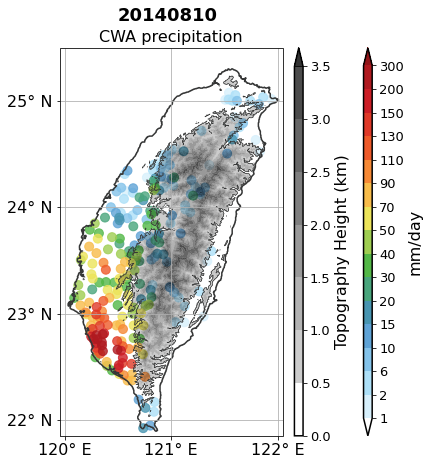

In [104]:
Plot_cwa_dpcp_add_settings(date='20140810', figname='revis')

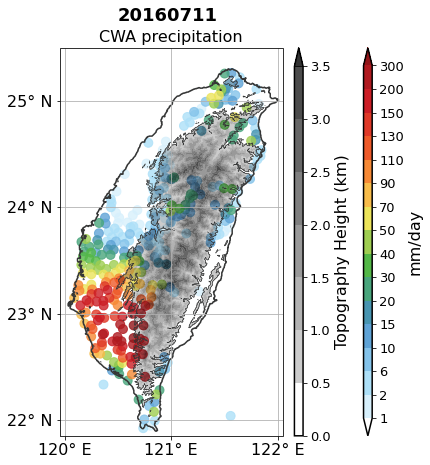

In [105]:
Plot_cwa_dpcp_add_settings(date='20160711', figname='revis')

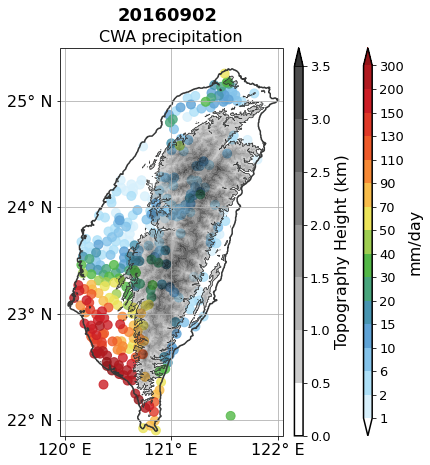

In [106]:
Plot_cwa_dpcp_add_settings(date='20160902', figname='revis')

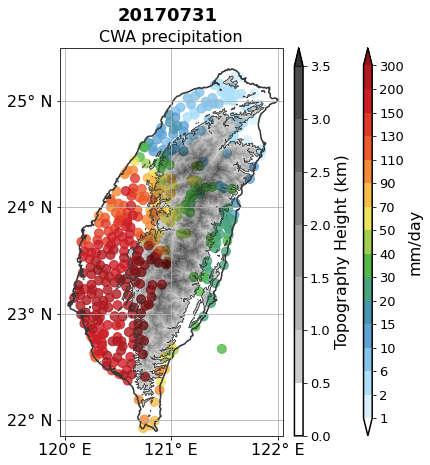

In [107]:
Plot_cwa_dpcp_add_settings(date='20170731', figname='revis')

## TaiwanVVM

In [118]:
def Plot_vvm_dpcp(case:str, date:str, swsuffix:str='', cbar=True, topo_contour_lw=0.5, pcp_on_top=False, regional_rect=False, land_only:bool=False, figtitle=False, figname=False):
    # Data initialize
    arr_day_pcp = cal_vvm_dpcp(case=case, date=date, land_only=land_only)
    # Figure initialize
    fig = plt.figure(figsize=(4, 8))
    gs  = GridSpec(1, 1, figure=fig)
    bounds = np.array([1, 2, 6, 10, 15, 20, 30, 40, 50, 70, 90, 110, 130, 150, 200, 300])
    # ----------------------------------------------------------------------------------------
    # Plot
    ax1   = plottools_vvm.Axe_map(fig, gs[0], xlim_=[119.95, 122.05], ylim_=[21.85, 25.5],
                                    xloc_=np.arange(120, 122.1, 1), yloc_=np.arange(22, 25.1, 1))
    plottools_vvm.Plot_vvm_map(ax1, c['dark grey'], 1.5)  # coastline
    ## precip.
    imvvm = plottools_vvm.Plot_vvm_pcp(ax1, np.where(arr_day_pcp>1, arr_day_pcp, np.nan), transform_option='map')
    if pcp_on_top:
        pcp_zorder = 20
        imvvm.set_zorder(pcp_zorder)
        imvvm.set_alpha(0.8)
    if cbar:
        cax  = fig.add_axes([ax1.get_position().x1+0.28, ax1.get_position().y0, 0.03, ax1.get_position().height])
        cbar = fig.colorbar(imvvm, orientation='vertical', cax=cax)
        cbar.solids.set(alpha=1)  # Default: set cbar to full color (w/out tranparency)
        cbar.set_ticks(ticks=bounds, labels=[int(i) for i in bounds])
        cbar.ax.tick_params(labelsize=13)
        cbar.set_label('mm/day', fontsize=16)
        cbar.outline.set_linewidth(1.5)
    ## topo
    topo_bounds= np.arange(0, 3500.1, 500)
    imtopoh    = plottools_vvm.Plot_vvm_topo(ax1, c['dark grey'], topo_contour_lw)
    if cbar:
        cax  = fig.add_axes([ax1.get_position().x1+0.04, ax1.get_position().y0, 0.03, ax1.get_position().height])
        cbar = fig.colorbar(imtopoh, orientation='vertical', cax=cax)
        cbar.set_ticks(ticks=topo_bounds, labels=[f"{i/1e3:.1f}" for i in topo_bounds])
        cbar.ax.tick_params(labelsize=13)
        cbar.set_label('Topography Height (km)', fontsize=16)
        cbar.outline.set_linewidth(1.5)
    
    ax1.set_xticklabels([f'{int(i)}\N{DEGREE SIGN} E' for i in np.arange(120, 122.1, 1)], fontsize=16) # fontsize changed from 20
    ax1.set_yticklabels([f'{int(i)}\N{DEGREE SIGN} N' for i in np.arange(22, 25.1, 1)], fontsize=16)
    if regional_rect:
        rect = patches.Rectangle((regional_rect[0], regional_rect[2]), regional_rect[1]-regional_rect[0], regional_rect[3]-regional_rect[2], 
                                 fc="none", ec=c['black'], linewidth=2, zorder=50, label='south-\nwestern')
        ax1.add_artist(rect)
        ax1.legend(handles=[rect], fontsize=13, loc='lower right')
    if figtitle:
        ax1.set_title(f'{figtitle}', loc='left', fontsize=20)
    else:
        ax1.set_title('VVM precipitation', fontsize=16)
        fig.suptitle(x=0.5, y=0.91, t=date, fontsize=18, fontweight='bold')
    if figname:
        plt.savefig(f'{vvmpcp_figpath}/{date}_{figname}.png', facecolor='w', bbox_inches='tight', dpi=400)
    plt.show()

Calculating daily precipitation. The Land-only option is now: True.


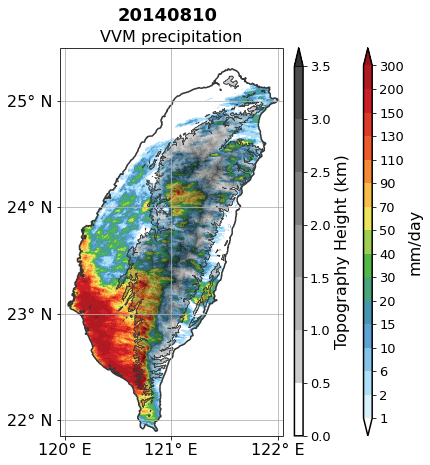

In [119]:
Plot_vvm_dpcp(case='sw', date=20140810, land_only=True, topo_contour_lw=0.6, figname='revis')

Calculating daily precipitation. The Land-only option is now: True.


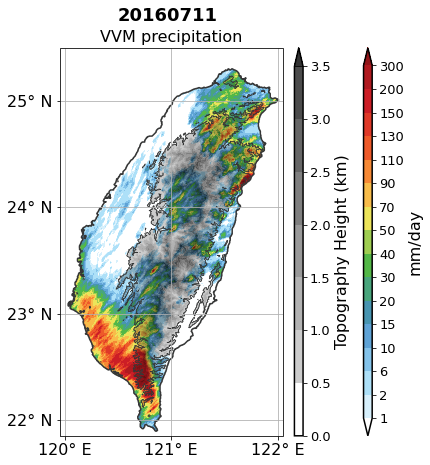

In [120]:
Plot_vvm_dpcp(case='sw', date=20160711, land_only=True, topo_contour_lw=0.6, figname='revis')

Calculating daily precipitation. The Land-only option is now: True.


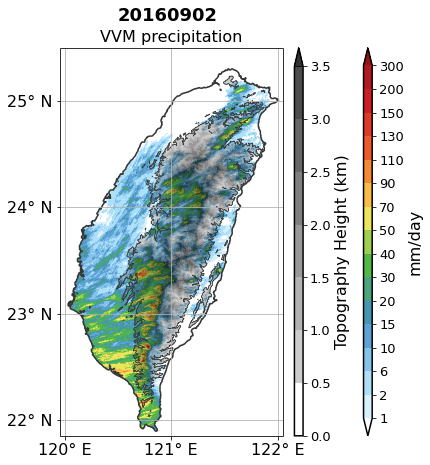

In [121]:
Plot_vvm_dpcp(case='sw', date=20160902, land_only=True, topo_contour_lw=0.6, figname='revis')

Calculating daily precipitation. The Land-only option is now: True.


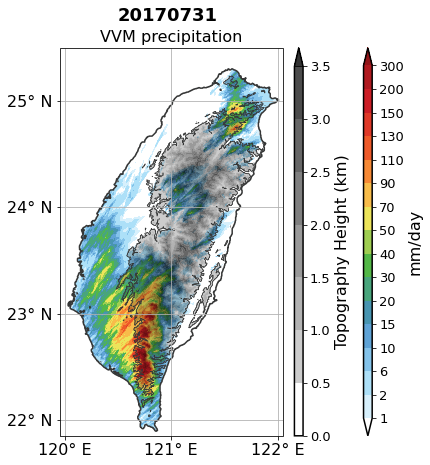

In [122]:
Plot_vvm_dpcp(case='sw', date=20170731, land_only=True, topo_contour_lw=0.6, figname='revis')